# 🎂 Age Group Classification
**Dataset:** 7,375 face images | **Classes:** `(0-20)` · `(20-40)` · `(40-100)`

**Arsitektur:** EfficientNetB0 (pretrained ImageNet) + Fine-tuning

| Split | (0-20) | (20-40) | (40-100) | Total |
|-------|--------|---------|----------|-------|
| Train | 1711   | 1721    | 1730     | 5162  |
| Valid | 512    | 489     | 471      | 1472  |
| Test  | 240    | 255     | 244      | 739   |

## Setup & Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# ─── SESUAIKAN PATH DI BAWAH INI ───────────────────────────────────────────
DATASET_ZIP = '/content/drive/MyDrive/age.v2i.folder.zip'  # ✅ Path ZIP di Google Drive
DATASET_DIR = '/content/age_dataset'                        # folder ekstrak
# ────────────────────────────────────────────────────────────────────────────

import zipfile, os
if not os.path.exists(DATASET_DIR):
    print('📦 Mengekstrak dataset...')
    with zipfile.ZipFile(DATASET_ZIP, 'r') as z:
        z.extractall(DATASET_DIR)
    print('✅ Selesai!')
else:
    print('✅ Dataset sudah ada, skip ekstrak.')


Mounted at /content/drive
📦 Mengekstrak dataset...
✅ Selesai!


##  1 — Install & Import

In [4]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights

from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU   : {torch.cuda.get_device_name(0)}')


🖥️  Device: cuda
   GPU   : Tesla T4


##  2 — Dataset & DataLoader

In [5]:
# ── Config
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_CLASSES = 3

TRAIN_DIR = os.path.join(DATASET_DIR, 'train')
VALID_DIR = os.path.join(DATASET_DIR, 'valid')
TEST_DIR  = os.path.join(DATASET_DIR, 'test')

# ── Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ── Datasets
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
valid_ds  = datasets.ImageFolder(VALID_DIR,  transform=eval_transform)
test_ds   = datasets.ImageFolder(TEST_DIR,   transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader  = DataLoader(valid_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader   = DataLoader(test_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = train_ds.classes
print('📁 Kelas:', CLASS_NAMES)
print(f'   Train : {len(train_ds):,} gambar')
print(f'   Valid : {len(valid_ds):,} gambar')
print(f'   Test  : {len(test_ds):,} gambar')

📁 Kelas: ['(0-20)', '(20-40)', '(40-100)']
   Train : 5,162 gambar
   Valid : 1,472 gambar
   Test  : 739 gambar


##  3 — Visualisasi Sample Data

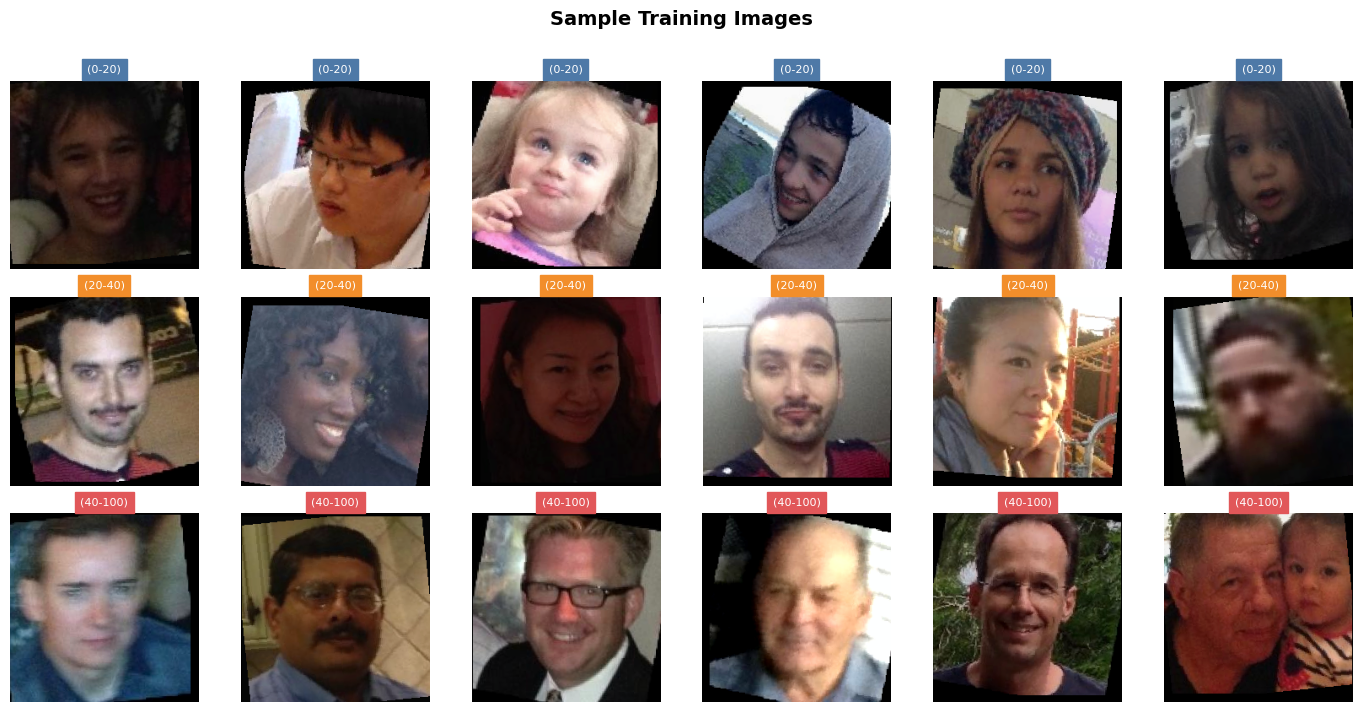

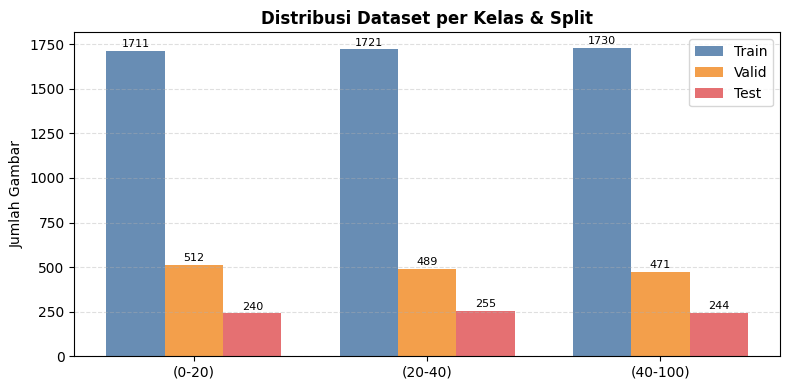

In [6]:
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = tensor.permute(1,2,0).numpy()
    return np.clip(img * STD + MEAN, 0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(3, 6, figsize=(14, 7))
fig.suptitle('Sample Training Images', fontsize=14, fontweight='bold', y=1.01)

COLORS = ['#4E79A7', '#F28E2B', '#E15759']
idx = 0
for row, cls_idx in enumerate(range(NUM_CLASSES)):
    cls_mask = (labels == cls_idx).nonzero(as_tuple=True)[0][:6]
    for col, i in enumerate(cls_mask):
        ax = axes[row][col]
        ax.imshow(denormalize(images[i]))
        ax.set_title(CLASS_NAMES[cls_idx], fontsize=8,
                     color='white', backgroundcolor=COLORS[cls_idx])
        ax.axis('off')

plt.tight_layout()
plt.show()

# ── Distribusi kelas (✅ hapus variabel counts yang tidak terpakai)
def count_images(cls_dir):
    """Hitung semua gambar (.jpg, .jpeg, .png) dalam folder."""
    exts = ('*.jpg', '*.jpeg', '*.png')
    return sum(len(list(Path(cls_dir).glob(ext))) for ext in exts)

fig, ax = plt.subplots(figsize=(8, 4))
splits = ['Train', 'Valid', 'Test']
split_dirs = [TRAIN_DIR, VALID_DIR, TEST_DIR]
x = np.arange(len(CLASS_NAMES))
width = 0.25

for i, (split, sdir) in enumerate(zip(splits, split_dirs)):
    cnts = [count_images(os.path.join(sdir, c)) for c in CLASS_NAMES]
    bars = ax.bar(x + i*width, cnts, width, label=split, color=COLORS[i], alpha=0.85)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+10,
                str(int(b.get_height())), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Jumlah Gambar')
ax.set_title('Distribusi Dataset per Kelas & Split', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


##  4 — Build Model (EfficientNetB0 + Fine-tuning)

In [7]:
def build_model(num_classes=3, freeze_backbone=True):
    """EfficientNetB0 pretrained, ganti classifier head."""
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    # Ganti head classifier
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)
    )
    return model.to(DEVICE)

model = build_model(num_classes=NUM_CLASSES, freeze_backbone=True)

total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'📊 Total params    : {total:,}')
print(f'   Trainable params: {trainable:,} ({100*trainable/total:.1f}%)')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 51.0MB/s]

📊 Total params    : 4,336,255
   Trainable params: 328,707 (7.6%)


##  5 — Training Loop

In [8]:
# ── Hyperparameter
EPOCHS_PHASE1 = 10   # Freeze backbone
EPOCHS_PHASE2 = 10   # Unfreeze + fine-tune
LR_PHASE1     = 1e-3
LR_PHASE2     = 1e-4

criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, leave=False, desc='Train'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, leave=False, desc='Valid'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


def run_training(model, epochs, lr, phase_name):
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    best_val_acc = 0

    # ✅ Fix: hindari nested quotes di f-string (error di Python < 3.12)
    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  {phase_name} — {epochs} epochs @ lr={lr}')
    print(f'{sep}')

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = eval_epoch(model, valid_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        marker = ''
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), '/content/best_model.pth')
            marker = ' ✅ saved'

        print(f'Epoch {epoch:02d}/{epochs} | '
              f'Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | '
              f'Val loss: {vl_loss:.4f} acc: {vl_acc:.4f}{marker}')

    print(f'\n🏆 Best Val Accuracy: {best_val_acc:.4f}')
    return history


In [9]:
# ── PHASE 1: Latih hanya classifier head (backbone difreeze)
hist1 = run_training(model, EPOCHS_PHASE1, LR_PHASE1, 'PHASE 1 — Head Only')


  PHASE 1 — Head Only — 10 epochs @ lr=0.001


Train:   0%|          | 0/162 [00:00<?, ?it/s]

Valid:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 01/10 | Train loss: 0.8505 acc: 0.6013 | Val loss: 0.7185 acc: 0.6909 ✅ saved


Train:   0%|          | 0/162 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 09/10 | Train loss: 0.6220 acc: 0.7245 | Val loss: 0.6109 acc: 0.7296


Train:   0%|          | 0/162 [00:00<?, ?it/s]

Valid:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 10/10 | Train loss: 0.6186 acc: 0.7270 | Val loss: 0.6048 acc: 0.7391 ✅ saved

🏆 Best Val Accuracy: 0.7391


In [10]:
# ── PHASE 2: Unfreeze seluruh backbone → fine-tune semua layer
for param in model.features.parameters():
    param.requires_grad = True

trainable2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'🔓 Backbone di-unfreeze. Trainable params: {trainable2:,}')

hist2 = run_training(model, EPOCHS_PHASE2, LR_PHASE2, 'PHASE 2 — Full Fine-Tuning')

🔓 Backbone di-unfreeze. Trainable params: 4,336,255

  PHASE 2 — Full Fine-Tuning — 10 epochs @ lr=0.0001


Train:   0%|          | 0/162 [00:00<?, ?it/s]

Valid:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 01/10 | Train loss: 0.5607 acc: 0.7518 | Val loss: 0.5125 acc: 0.7901 ✅ saved


Train:   0%|          | 0/162 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 09/10 | Train loss: 0.1591 acc: 0.9450 | Val loss: 0.4278 acc: 0.8417 ✅ saved


Train:   0%|          | 0/162 [00:00<?, ?it/s]

Valid:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 10/10 | Train loss: 0.1499 acc: 0.9438 | Val loss: 0.4235 acc: 0.8410

🏆 Best Val Accuracy: 0.8417


## 6 — Plot Training History

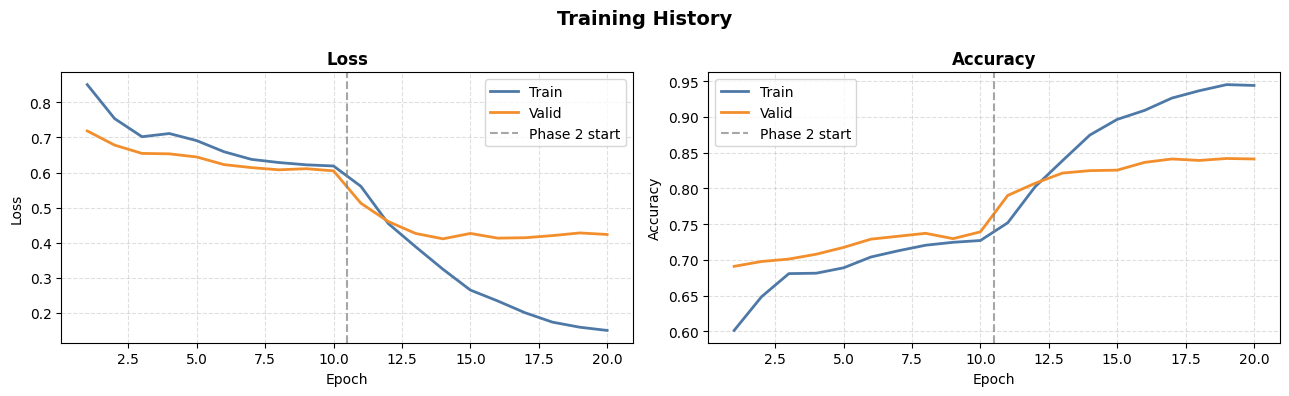

In [11]:
def plot_history(h1, h2):
    n1 = len(h1['train_loss'])
    n2 = len(h2['train_loss'])
    epochs_all = list(range(1, n1 + n2 + 1))

    train_loss = h1['train_loss'] + h2['train_loss']
    val_loss   = h1['val_loss']   + h2['val_loss']
    train_acc  = h1['train_acc']  + h2['train_acc']
    val_acc    = h1['val_acc']    + h2['val_acc']

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Training History', fontsize=14, fontweight='bold')

    for ax, train_m, val_m, title, ylabel in zip(
        axes,
        [train_loss, train_acc],
        [val_loss,   val_acc],
        ['Loss', 'Accuracy'],
        ['Loss', 'Accuracy']
    ):
        ax.plot(epochs_all, train_m, label='Train', color='#4E79A7', linewidth=2)
        ax.plot(epochs_all, val_m,   label='Valid', color='#F28E2B', linewidth=2)
        ax.axvline(n1 + 0.5, color='gray', linestyle='--', alpha=0.7, label='Phase 2 start')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_history(hist1, hist2)

##  7 — Evaluasi pada Test Set

Testing:   0%|          | 0/24 [00:00<?, ?it/s]


📋 Classification Report:
              precision    recall  f1-score   support

      (0-20)       0.92      0.85      0.88       240
     (20-40)       0.76      0.85      0.80       255
    (40-100)       0.86      0.81      0.83       244

    accuracy                           0.84       739
   macro avg       0.84      0.84      0.84       739
weighted avg       0.84      0.84      0.84       739



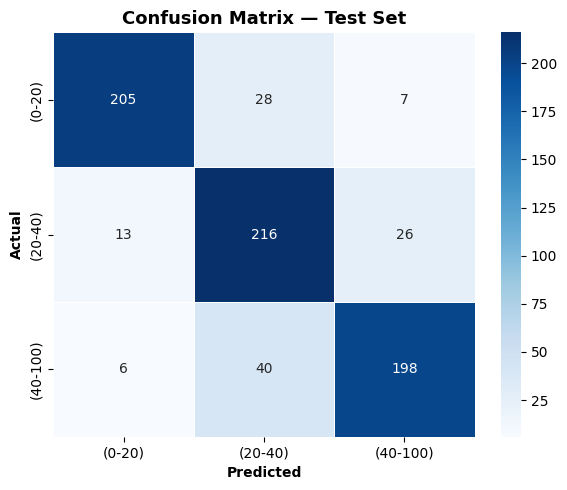

In [12]:
# Load best model
model.load_state_dict(torch.load('/content/best_model.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Testing'):
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print('\n📋 Classification Report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# ── Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual', fontweight='bold')
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8 — Prediksi Gambar Baru


🖼️  File : coarse_tilt_aligned_face-1547-11833529066_8c04e633ed_o_jpg.rf.036de6dd3dc383dcf5784cf879ec15e2.jpg
   Label asli: (0-20)


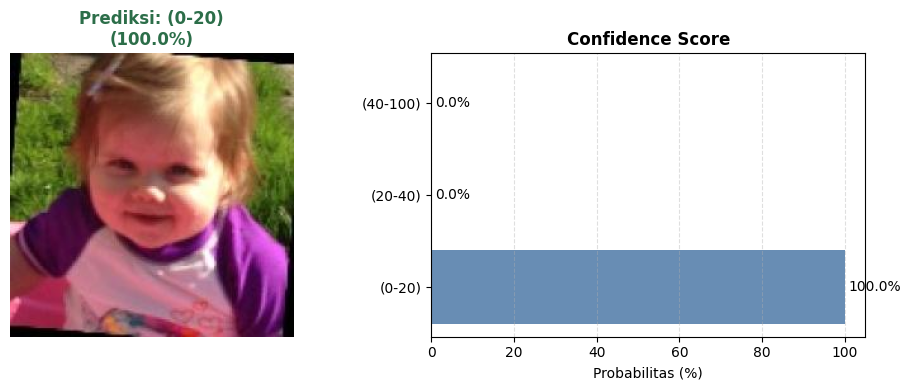


🖼️  File : face_-128-128-_0260_jpg.rf.fb610d9dc64bccf2a20f3d97ce183320.jpg
   Label asli: (20-40)


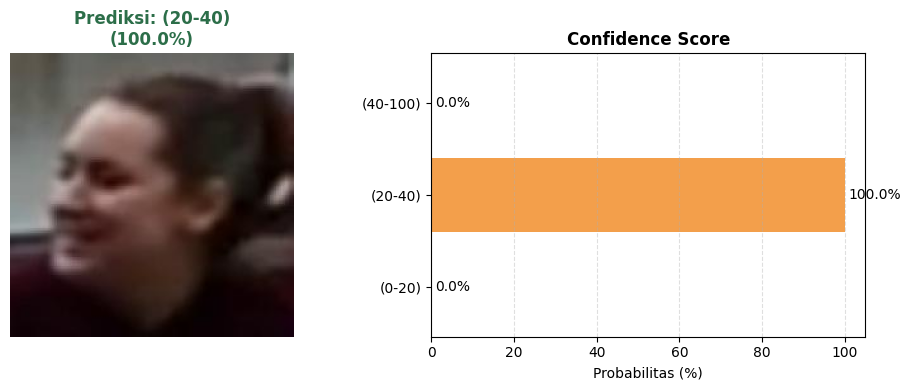


🖼️  File : coarse_tilt_aligned_face-1392-10695491646_c857108670_o_jpg.rf.9d1784ce3aa5a0bb4552a5fdbc52f13a.jpg
   Label asli: (40-100)


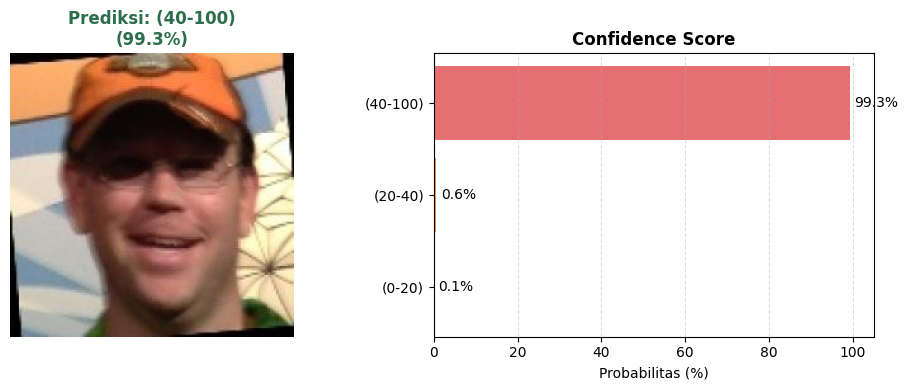

In [13]:
from PIL import Image

def predict_image(image_path, model, transform, class_names, device):
    """Prediksi 1 gambar dan tampilkan hasilnya."""
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred_idx  = probs.argmax()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title(f'Prediksi: {class_names[pred_idx]}\n({probs[pred_idx]*100:.1f}%)',
                      fontsize=12, fontweight='bold', color='#2c6e49')

    COLORS = ['#4E79A7', '#F28E2B', '#E15759']
    bars = axes[1].barh(class_names, probs * 100, color=COLORS, alpha=0.85)
    axes[1].set_xlim(0, 105)
    axes[1].set_xlabel('Probabilitas (%)')
    axes[1].set_title('Confidence Score', fontweight='bold')
    for bar, prob in zip(bars, probs):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{prob*100:.1f}%', va='center', fontsize=10)
    axes[1].grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()
    return class_names[pred_idx], probs


# ── Contoh: prediksi beberapa gambar dari test set
test_images = []
for cls in CLASS_NAMES:
    cls_dir = os.path.join(TEST_DIR, cls)
    # ✅ Support .jpg, .jpeg, .png
    exts = ('*.jpg', '*.jpeg', '*.png')
    imgs = [p for ext in exts for p in Path(cls_dir).glob(ext)]
    if imgs:
        test_images.append(random.choice(imgs))

for img_path in test_images:
    label_true = Path(img_path).parent.name
    print(f'\n🖼️  File : {Path(img_path).name}')
    print(f'   Label asli: {label_true}')
    predict_image(img_path, model, eval_transform, CLASS_NAMES, DEVICE)

# 9 — Simpan Model

In [14]:
# ── Simpan ke Google Drive
SAVE_PATH_DRIVE = '/content/drive/MyDrive/age_classifier_efficientnet.pth'

torch.save({
    'model_state_dict' : model.state_dict(),
    'class_names'      : CLASS_NAMES,
    'img_size'         : IMG_SIZE,
    'architecture'     : 'efficientnet_b0',
}, SAVE_PATH_DRIVE)

print(f'✅ Model disimpan ke: {SAVE_PATH_DRIVE}')

✅ Model disimpan ke: /content/drive/MyDrive/age_classifier_efficientnet.pth
